### Speed dating 

### Importy

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
)

from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

In [36]:
file_name = "speed_dating.csv"

if not os.path.exists(file_name):
    speed_dating = fetch_openml(data_id=40536, as_frame=True)
    df = speed_dating.frame
    df.to_csv(file_name, index=False)
    print(f"Dane zapisane lokalnie jako {file_name}!")

else:
    print(f"Znaleziono plik {file_name}, wczytuję z dysku...")
    df = pd.read_csv(file_name)

print(f"Rozmiar danych: {df.shape}")

Znaleziono plik speed_dating.csv, wczytuję z dysku...
Rozmiar danych: (8378, 121)


In [37]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 121 columns):
 #    Column                           Dtype  
---   ------                           -----  
 0    has_null                         int64  
 1    wave                             int64  
 2    gender                           str    
 3    age                              float64
 4    age_o                            float64
 5    d_age                            int64  
 6    d_d_age                          str    
 7    race                             str    
 8    race_o                           str    
 9    samerace                         int64  
 10   importance_same_race             float64
 11   importance_same_religion         float64
 12   d_importance_same_race           str    
 13   d_importance_same_religion       str    
 14   field                            str    
 15   pref_o_attractive                float64
 16   pref_o_sincere                   float64
 17   pref

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
has_null,8378.0,0.874910,0.330840,0.0,1.0,1.0,1.0,1.0
wave,8378.0,11.350919,5.995903,1.0,7.0,11.0,15.0,21.0
age,8283.0,26.358928,3.566763,18.0,24.0,26.0,28.0,55.0
age_o,8274.0,26.364999,3.563648,18.0,24.0,26.0,28.0,55.0
d_age,8378.0,4.185605,4.596171,0.0,1.0,3.0,5.0,37.0
...,...,...,...,...,...,...,...,...
expected_num_matches,7205.0,3.207814,2.444813,0.0,2.0,3.0,4.0,18.0
like,8138.0,6.134087,1.841285,0.0,5.0,6.0,7.0,10.0
guess_prob_liked,8069.0,5.207523,2.129565,0.0,4.0,5.0,7.0,10.0
met,8003.0,0.049856,0.282168,0.0,0.0,0.0,0.0,8.0


### Niezbalansowanie klasy docelowej

Match rate: 16.5%
match
0    6998
1    1380
Name: count, dtype: int64



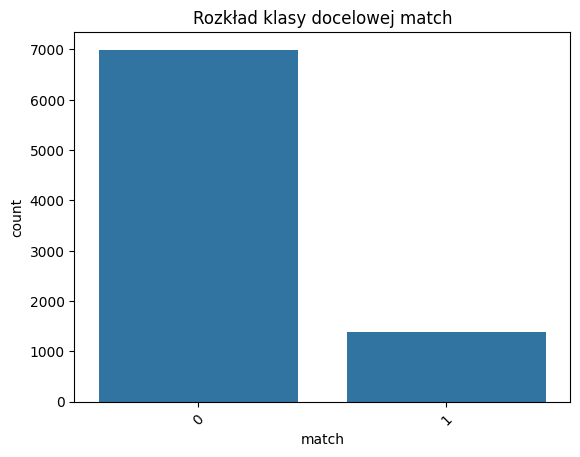

In [39]:
print(f"Match rate: {df['match'].mean():.1%}")
print(df["match"].value_counts())
print()

sns.countplot(x=df["match"], data=df)
plt.xticks(rotation=45)
plt.title("Rozkład klasy docelowej match")
plt.show()

- Klasa `match` jest silnie niezbalansowana (~16% pozytywów). Model uczący się na takich danych będzie miał tendencję do przewidywania klasy większościowej, dlatego później zastosujemy techniki dla danych niezbalansowanych.

### Badanie korelacji

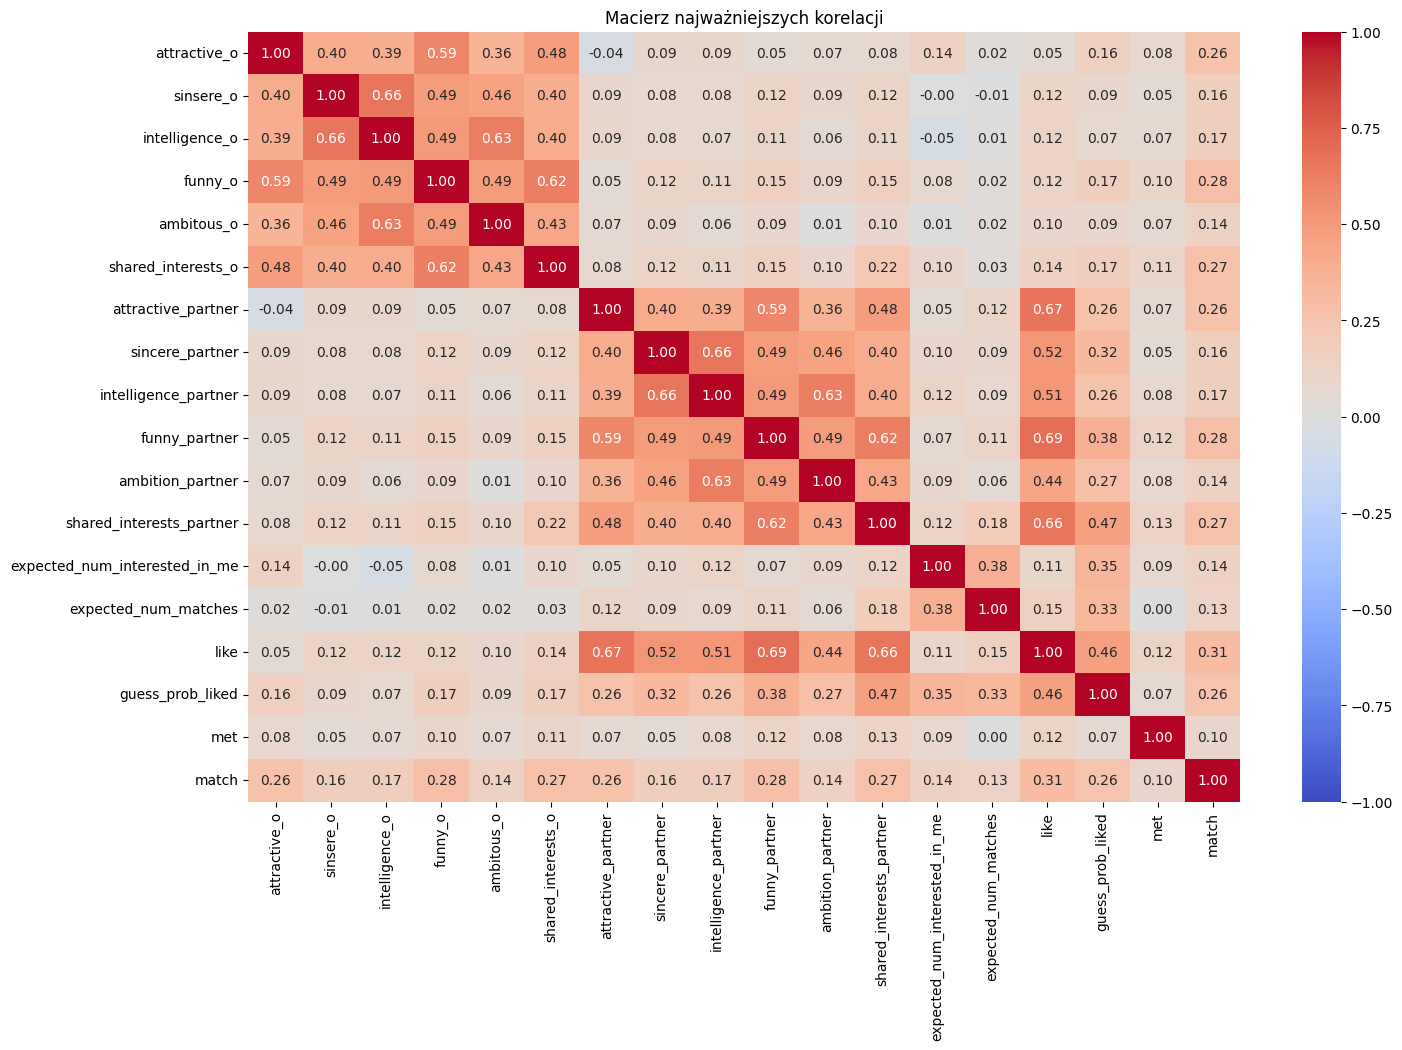

In [40]:
plt.figure(figsize=(16, 10))
encoded = pd.concat([df.drop(columns="match"), df["match"]], axis=1)
corr = encoded.corr(numeric_only=True)
target_corr = corr["match"]
significant_corr = target_corr[target_corr.abs() > 0.1].index.to_list()
sns.heatmap(
    corr.loc[significant_corr, significant_corr],
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
)
plt.title("Macierz najważniejszych korelacji")
plt.show()

### Ciekawe zależności

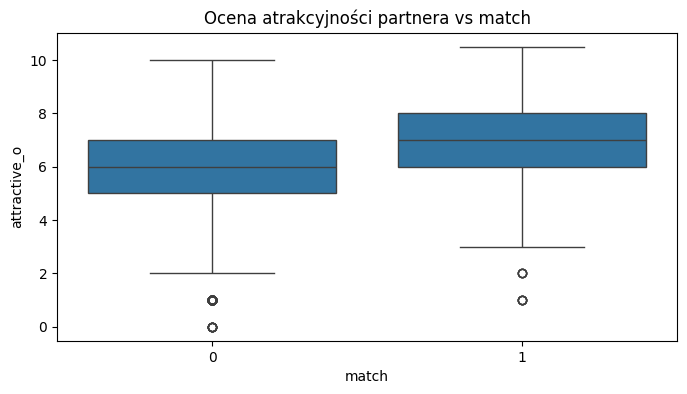

In [41]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="match", y="attractive_o")
plt.title("Ocena atrakcyjności partnera vs match")
plt.show()

- Jak ktoś jest atrakcyjny to raczej będzie miał matcha.

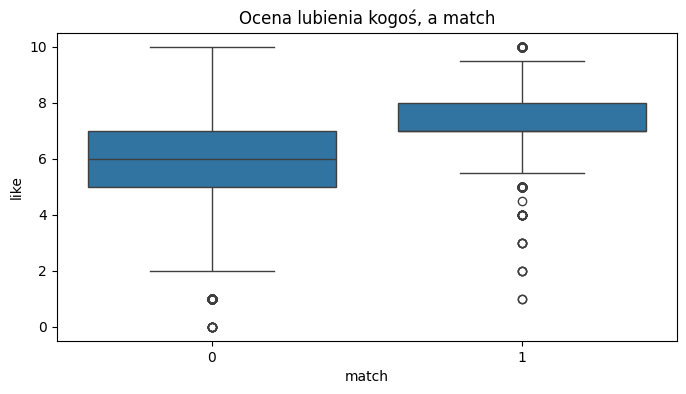

In [42]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="match", y="like")
plt.title("Ocena lubienia kogoś, a match")
plt.show()

- Jak kogoś się lubi to raczej jest match.

### Cechy profilowe vs match

Cechy dostępne przed randką — to właśnie na nich będziemy budować model.

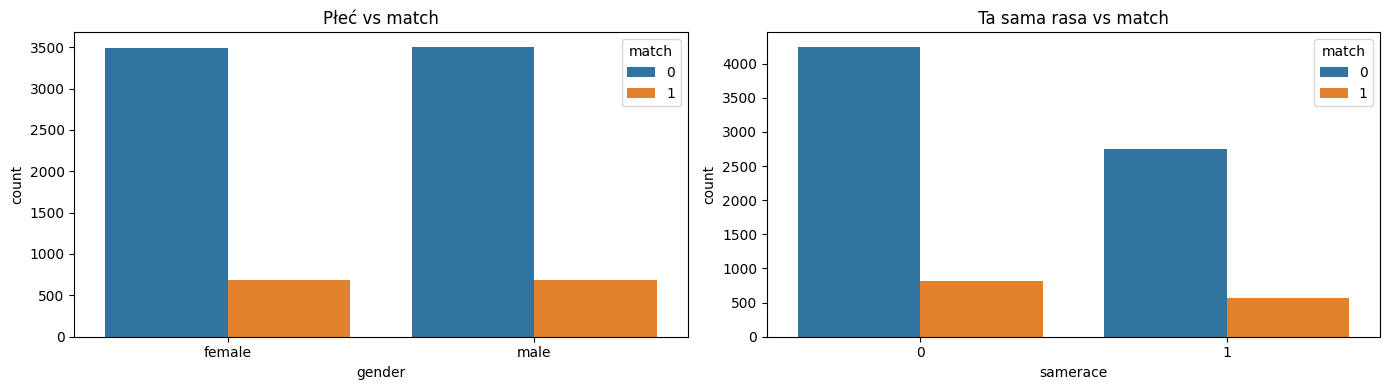

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="gender", hue="match", ax=axes[0])
axes[0].set_title("Płeć vs match")

sns.countplot(data=df, x="samerace", hue="match", ax=axes[1])
axes[1].set_title("Ta sama rasa vs match")

plt.tight_layout()
plt.show()

- Proporcja matchów jest podobna u obu płci.
- Wspólna rasa (`samerace=1`) nieznacznie zwiększa udział matchów.

### Sprawdzanie braków

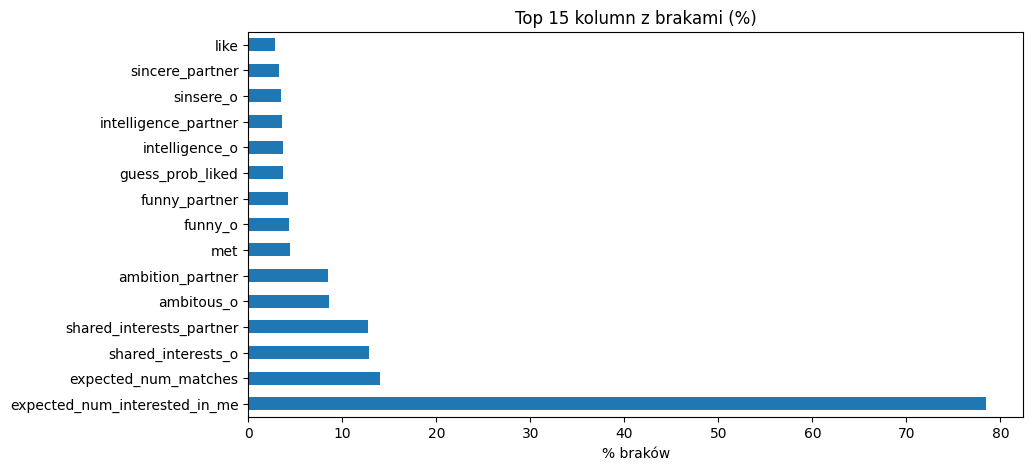

In [44]:
missing_pct = df.isnull().mean().sort_values(ascending=False).head(15) * 100
missing_pct.plot(kind="barh", figsize=(10, 5), title="Top 15 kolumn z brakami (%)")
plt.xlabel("% braków")
plt.show()

Kolumny takie jak `*_partner`, `*_o`, `like` i `interests_correlate` pochodzą z randki, a nie z profilu użytkownika. Silnie wiążą się z `match` (widać to na wykresach powyżej), więc stanowią wyciek informacji. Usuwamy je przed modelowaniem i zostawiamy wyłącznie cechy profilowe dostępne w momencie rekomendacji.

### Usuwanie kolumn, które dają wyciek danych.

In [45]:
leakage_cols = [
    "attractive_o",
    "sinsere_o",
    "intelligence_o",
    "funny_o",
    "ambitous_o",
    "shared_interests_o",
    "d_attractive_o",
    "d_sinsere_o",
    "d_intelligence_o",
    "d_funny_o",
    "d_ambitous_o",
    "d_shared_interests_o",
    "attractive_partner",
    "sincere_partner",
    "intelligence_partner",
    "funny_partner",
    "ambition_partner",
    "shared_interests_partner",
    "d_attractive_partner",
    "d_sincere_partner",
    "d_intelligence_partner",
    "d_funny_partner",
    "d_ambition_partner",
    "d_shared_interests_partner",
    "like",
    "d_like",
    "guess_prob_liked",
    "d_guess_prob_liked",
    "wave",
    "interests_correlate",
    "d_interests_correlate",
]

df.drop(columns=leakage_cols, inplace=True)
print(f"Rozmiar po usunięciu wycieków: {df.shape}")

Rozmiar po usunięciu wycieków: (8378, 90)


In [46]:
df["field"] = df["field"].str.lower().str.strip()

- Kolumna field zawiera np. law i Law

### Profilowanie

In [47]:
profile_cols = [
    "gender",
    "age",
    "race",
    "field",
    "sports",
    "tvsports",
    "exercise",
    "dining",
    "museums",
    "art",
    "hiking",
    "gaming",
    "clubbing",
    "reading",
    "tv",
    "theater",
    "movies",
    "concerts",
    "music",
    "shopping",
    "yoga",
]

df_filled = df[profile_cols].fillna("Missing")
user_ids = df_filled.groupby(profile_cols).ngroup()
user_counts = user_ids.value_counts()
relevant_users = user_counts[user_counts >= 5].index
train_users, test_users = train_test_split(
    relevant_users, test_size=0.2, random_state=67
)

### Podział danych względem usera. 

In [48]:
test_indices = []
for user in test_users:
    u_idx = user_ids[user_ids == user].index
    test_indices.extend(u_idx[:5])
train_indices = user_ids[user_ids.isin(train_users)].index
X_train = df.loc[train_indices].drop(columns=["match"])
y_train = df.loc[train_indices]["match"]
X_test = df.loc[test_indices].drop(columns=["match"])
y_test = df.loc[test_indices]["match"]
user_ids_train = user_ids.loc[train_indices]
user_ids_test = user_ids.loc[test_indices]
print(f"Dane treningowe (X_train): {X_train.shape}")
print(f"Dane testowe (X_test): {X_test.shape}")

Dane treningowe (X_train): (6712, 89)
Dane testowe (X_test): (550, 89)


### Imputacja danych

In [49]:
assert y_train.isnull().sum() == 0
assert y_test.isnull().sum() == 0

- Nie ma braków w zmiennej celu.

In [50]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

expected_num_interested_in_me    5266
expected_num_matches              887
met                               297
pref_o_shared_interests           103
expected_happy_with_sd_people     101
shared_interests_important         99
ambtition_important                99
age                                95
funny_important                    89
funny                              87
sincere                            87
ambition                           87
intelligence                       87
attractive                         87
pref_o_ambitious                   84
age_o                              83
gaming                             79
clubbing                           79
reading                            79
tv                                 79
theater                            79
art                                79
movies                             79
concerts                           79
music                              79
shopping                           79
yoga        

In [51]:
missing_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
missing_pct

expected_num_interested_in_me    78.456496
expected_num_matches             13.215137
met                               4.424911
pref_o_shared_interests           1.534565
expected_happy_with_sd_people     1.504768
                                   ...    
d_shared_interests_important      0.000000
d_attractive                      0.000000
gender                            0.000000
d_intelligence                    0.000000
d_sincere                         0.000000
Length: 89, dtype: float64

In [52]:
X_train.drop(columns="has_null", inplace=True)
X_test.drop(columns="has_null", inplace=True)

- Data Leakage, kolumna, która wskazywała, czy są Nany.

In [53]:
X_train.drop(columns="expected_num_interested_in_me", inplace=True)
X_test.drop(columns="expected_num_interested_in_me", inplace=True)

- Usuwamy tą kolumnę, ponieważ braki sięgają 78 procent.

In [54]:
col = "expected_num_matches"
np.random.seed(67)
valid = X_train[col].dropna().values
mask_tr = X_train[col].isna()
mask_te = X_test[col].isna()
X_train.loc[mask_tr, col] = np.random.choice(valid, size=mask_tr.sum())
if mask_te.sum() > 0:
    X_test.loc[mask_te, col] = np.random.choice(valid, size=mask_te.sum())

- Ta kolumna ma aż 13 procent braków. Wypełniam ją losowymi prawidłowymi wartościami, by zachować rozkład.

In [55]:
d_cols = [c for c in X_train.columns if c.startswith("d_")]
X_train.drop(columns=d_cols, inplace=True)
X_test.drop(columns=d_cols, inplace=True)

- Usuwamy zbędne dane, kolumny z d_ zawierają zdyskretyzowane inne dane np d_sports dostaje d_age.

In [56]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
medians = X_train[numeric_cols].median()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns
modes = X_train[categorical_cols].mode().iloc[0]

X_train[categorical_cols] = X_train[categorical_cols].fillna(modes)
X_test[categorical_cols] = X_test[categorical_cols].fillna(modes)

- Resztę braków wypełniam medianą dla danych numerycznych i modą dla kategorycznych

In [57]:
hobby_cols = profile_cols[4:]
X_train["shared_interests_ratio"] = X_train["pref_o_shared_interests"] / X_train[
    hobby_cols
].sum(axis=1)
X_test["shared_interests_ratio"] = X_test["pref_o_shared_interests"] / X_test[
    hobby_cols
].sum(axis=1)
X_train["shared_interests_ratio"] = X_train["shared_interests_ratio"].fillna(0)
X_test["shared_interests_ratio"] = X_test["shared_interests_ratio"].fillna(0)

- Dodaję cechę ile procent hobby się pokrywa z partnerem.

In [58]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
print(X_train.shape)

(6712, 242)


- Stosuję `One-Hot-Encoding` dla danych kategorycznych. 

In [59]:
assert sum(X_train.isnull().sum()) == 0
assert sum(X_test.isnull().sum()) == 0

- Już nie ma braków

### Baseline

In [60]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = y_pred
        roc_auc = None

    return {
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": average_precision_score(y_test, y_score),
    }

In [61]:
baseline_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "dummy_stratified": DummyClassifier(strategy="stratified", random_state=42),
    "logreg_default": LogisticRegression(max_iter=2000, random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
}

rows = []
for name, model in baseline_models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["model"] = name
    rows.append(metrics)

baseline_results = pd.DataFrame(rows)[
    ["model", "recall", "f2", "precision", "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)

baseline_results

,model,recall,f2,precision,roc_auc,pr_auc
3,decision_tree,0.250000,0.238636,0.201923,0.540836,0.165702
1,dummy_stratified,0.202381,0.195402,0.171717,0.513208,0.156570
0,dummy_most_frequent,0.000000,0.000000,0.000000,0.500000,0.152727
2,logreg_default,0.000000,0.000000,0.000000,0.569232,0.191294


- Wyniki są beznadziejne, ponieważ model przewiduje klasę większościową.

### Przewidywanie klasy mniejszościowej.

In [62]:
model = LogisticRegression(max_iter=2000, random_state=67)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report_imbalanced(y_test, y_pred))

                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.99      0.00      0.91      0.00      0.00       466
          1       0.00      0.00      0.99      0.00      0.00      0.00        84

avg / total       0.72      0.84      0.15      0.77      0.00      0.00       550



- Model dla klasy większościowej przewiduje dość dobrze recall 99 procent i precision 85 procent. A 0 wszystkich miar jakościowych, jeśli chodzi o klasę mniejszościową. 

### TSNE przed zastosowaniem resamplingu.

In [63]:
def give_samples(X,y,n):
    if len(X) > n:
        indices = np.random.RandomState(seed=67).choice(len(X), size=n, replace=False)
        X_sampled = X.iloc[indices]
        y_sampled = y.iloc[indices]
    else:
        X_sampled = X
        y_sampled = y
    return (X_sampled, y_sampled)


- Funkcja do dawania określonej ilości próbek.

In [64]:
tsne = TSNE(
    n_components = 2,
    perplexity = 30,
    learning_rate = "auto",
    max_iter = 1500,
    random_state = 67,
    n_jobs = -1
)

X_sampled, y_sampled = give_samples(X_train, y_train, 1500)
X_embedded = tsne.fit_transform(X_sampled)
print(X_embedded.shape)


(1500, 2)


- Obliczanie embeddingu t-SNE na losowym podzbiorze 1500 próbek z danych treningowych.

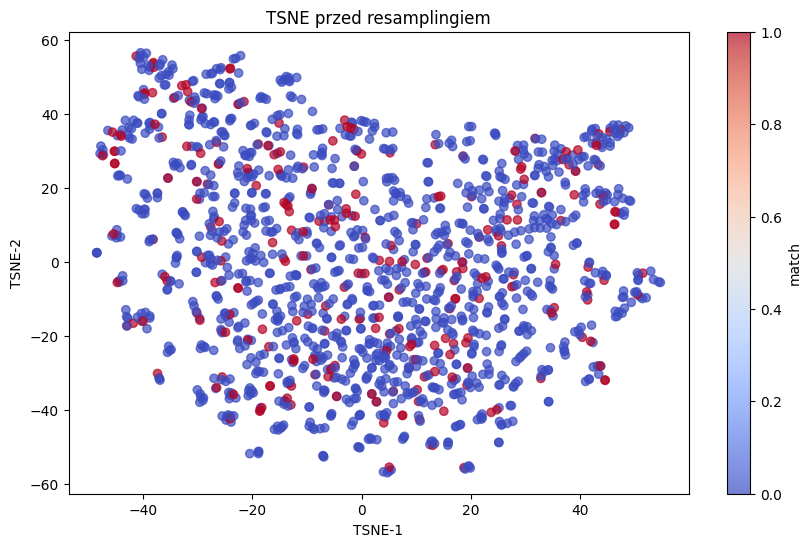

In [65]:
def generate_tsne_scatter(X_embedded, y, title):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap="coolwarm", alpha=0.7)
    plt.colorbar(scatter, label="match")
    plt.title(title)
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.show()

generate_tsne_scatter(X_embedded, y_sampled, "TSNE przed resamplingiem")

- Dominuje kolor niebieski, brak matcha. Świadczy to niezbilansowaniu zmiennej celu. Ponadto kolory są wymieszane, co świadczy o tym, że klasyfikacja jest słaba, nie widać wyraźnych skupisk.

### Zastosowanie SMOTE

(1500, 2)


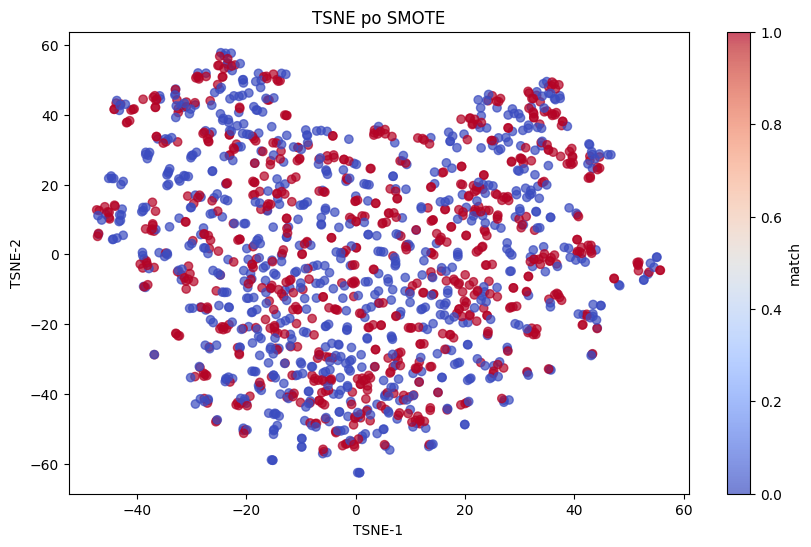

In [66]:
smote = SMOTE(random_state=67)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1500,
    random_state=67,
    n_jobs=-1,
)

X_sampled_smote, y_sampled_smote = give_samples(X_train_smote, y_train_smote, 1500)
X_embedded_smote = tsne.fit_transform(X_sampled_smote)
print(X_embedded_smote.shape)
generate_tsne_scatter(X_embedded_smote, y_sampled_smote, "TSNE po SMOTE")



- Widać już że jest porówno czerwonych jak i niebieskich kropek. Jeśli chodzi o klasyfikację, to już widać jakieś skupiska bardziej czerwone, czy też niebieskie, lecz dalej jest to problematyczne do rozróżnienia.